In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

2026-02-06 06:58:59.248408: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770361139.662862      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770361139.780692      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770361140.856859      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770361140.856886      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770361140.856889      55 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_csv('/kaggle/input/low-resolution-lamost-big-star-data/lowdr7lamost.csv', sep='|', engine='python')

In [3]:
df.describe()

,combined_obsid,combined_lmjd,combined_mjd,combined_spid,combined_fiberid,combined_z,combined_ra,combined_dec,combined_logg,combined_feh,combined_teff,combined_rv,combined_m_h
count,6.759593e+06,6.759593e+06,6.759593e+06,6.759593e+06,6.759593e+06,6.759593e+06,6.759593e+06,6.759593e+06,5.919883e+06,5.743502e+06,5.919883e+06,5.743502e+06,170634.000000
mean,3.342138e+08,5.712801e+04,5.712701e+04,8.433005e+00,1.260223e+02,-1.495528e+00,1.436772e+02,2.666133e+01,-9.681815e+00,-2.352946e-01,5.528113e+03,-8.612024e+00,-360.830770
std,1.954245e+08,6.947059e+02,6.947059e+02,4.568767e+00,7.097084e+01,1.222755e+02,9.130852e+01,1.677645e+01,3.700114e+02,3.424437e-01,1.176904e+03,4.636232e+01,1863.838084
min,1.010010e+05,5.585900e+04,5.585800e+04,1.000000e+00,1.000000e+00,-9.999000e+03,1.100000e-04,-9.906984e+00,-9.999000e+03,-2.500000e+00,-9.999000e+03,-4.993100e+02,-9999.000000
25%,1.745160e+08,5.660300e+04,5.660200e+04,4.000000e+00,6.500000e+01,-1.083416e-04,7.829078e+01,1.381991e+01,3.937000e+00,-4.130000e-01,4.957875e+03,-3.278000e+01,-0.681000
50%,3.081111e+08,5.705300e+04,5.705200e+04,8.000000e+00,1.260000e+02,-2.461700e-05,1.207342e+02,2.681180e+01,4.197000e+00,-1.960000e-01,5.596000e+03,-8.100000e+00,-0.400000
75%,4.806110e+08,5.769700e+04,5.769600e+04,1.200000e+01,1.870000e+02,6.107560e-05,2.049242e+02,4.005842e+01,4.457000e+00,-8.000000e-03,6.037510e+03,1.721000e+01,-0.033000
max,7.469152e+08,5.864300e+04,5.864200e+04,1.600000e+01,2.500000e+02,1.995510e+00,3.599999e+02,8.311561e+01,9.748000e+00,1.000000e+00,7.569935e+04,4.981000e+02,0.500000


In [4]:
df.shape

(6759593, 17)

In [5]:
df.isna().sum()

combined_obsid             0
combined_obsdate           0
combined_lmjd              0
combined_mjd               0
combined_planid            0
combined_spid              0
combined_fiberid           0
combined_class             0
combined_subclass          0
combined_z                 0
combined_ra                0
combined_dec               0
combined_logg         839710
combined_feh         1016091
combined_teff         839710
combined_rv          1016091
combined_m_h         6588959
dtype: int64

### cleaning

In [6]:
df = df.drop_duplicates()

In [7]:
df.shape

(6759593, 17)

In [8]:
df = df.dropna(subset=['combined_teff', 'combined_logg', 'combined_feh', 'combined_z'])

In [9]:
df.shape

(5743502, 17)

In [10]:
df.isna().sum()

combined_obsid             0
combined_obsdate           0
combined_lmjd              0
combined_mjd               0
combined_planid            0
combined_spid              0
combined_fiberid           0
combined_class             0
combined_subclass          0
combined_z                 0
combined_ra                0
combined_dec               0
combined_logg              0
combined_feh               0
combined_teff              0
combined_rv                0
combined_m_h         5743502
dtype: int64

In [11]:
df['combined_spectral_class'] = df['combined_subclass'].str[0]

In [12]:
df['combined_spectral_class'].unique()

array(['G', 'F', 'K', 'A'], dtype=object)

In [13]:
for i in df['combined_spectral_class'].unique():
    print(f'{i}:', sum((df['combined_spectral_class'] == i) == True)/df.shape[0]*100, '%')

G: 50.8944020564457 %
F: 31.475604953214955 %
K: 15.66121157440182 %
A: 1.9687814159375236 %


#### Unavailability of Class O, A, M is a DR7 limitation or survey limitation

In [30]:
spectral_order = {
    'A': 0,
    'F': 1,
    'G': 2,
    'K': 3
}

df['combined_spectral_label'] = df['combined_spectral_class'].map(spectral_order)

## Intent: I want a fair classifier for all present classes (A, F, G, K)

# Data Visualization

/tmp/ipykernel_55/511643903.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='combined_spectral_class', palette='viridis', order=df['combined_spectral_class'].value_counts().index)


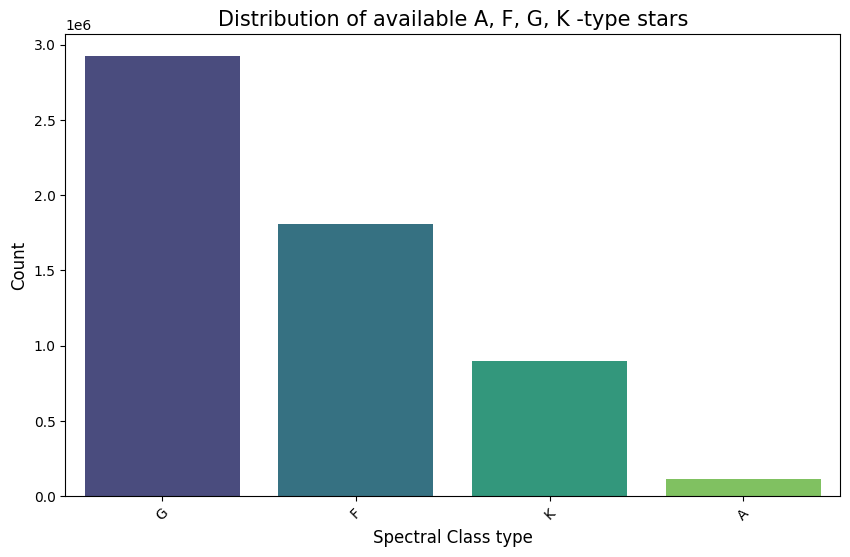

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='combined_spectral_class', palette='viridis', order=df['combined_spectral_class'].value_counts().index)

plt.title('Distribution of available A, F, G, K -type stars', fontsize=15)
plt.xlabel('Spectral Class type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

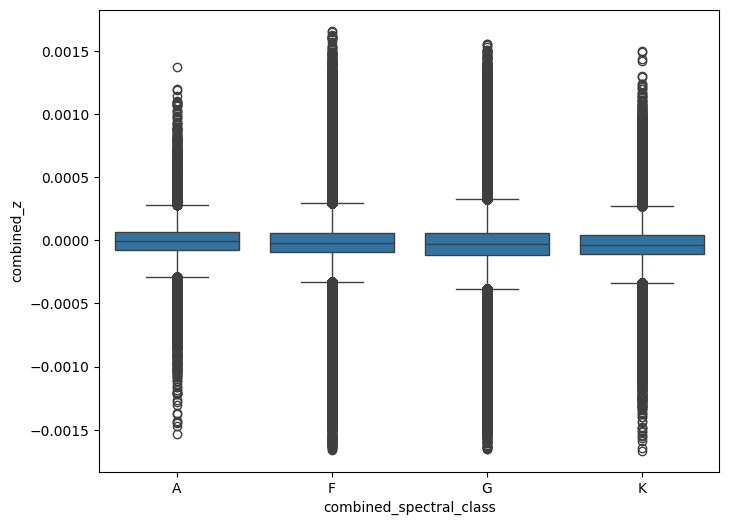

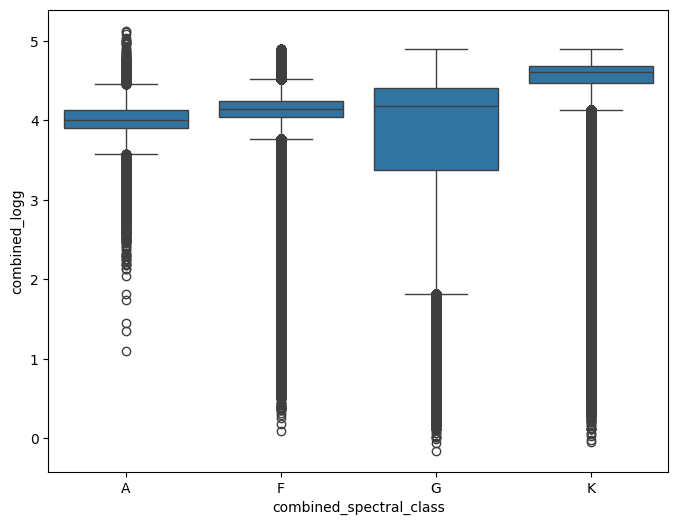

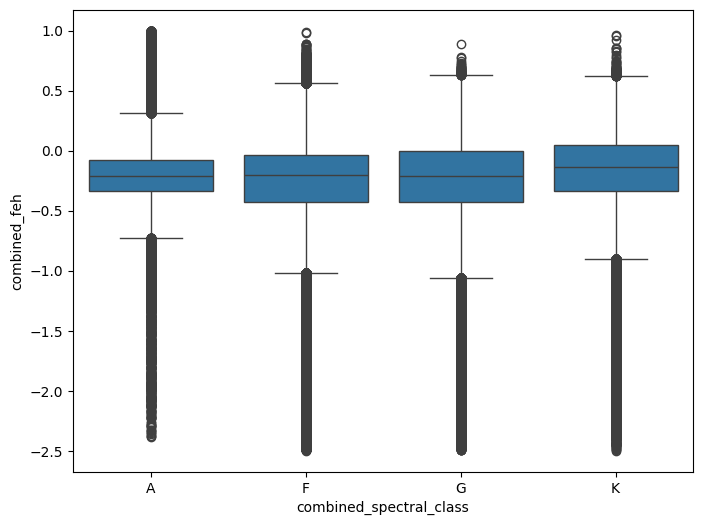

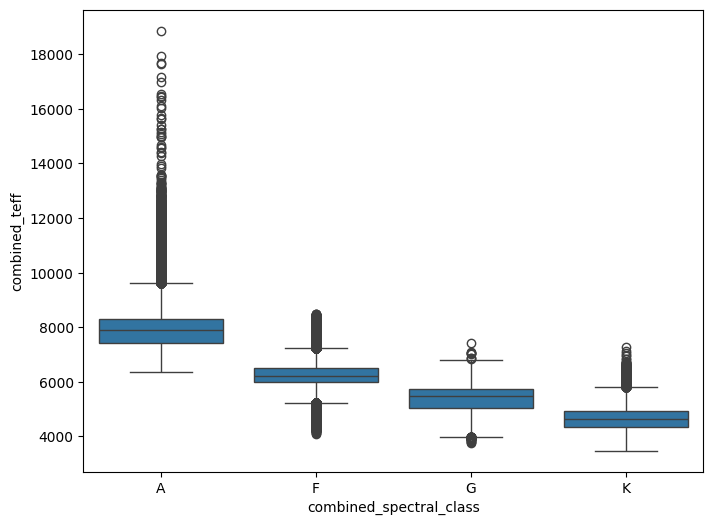

In [33]:
effective_features = ['combined_z', 'combined_logg', 'combined_feh', 'combined_teff',]

for i in effective_features:
    plt.figure(figsize=(8,6))
    sns.boxplot(
        x='combined_spectral_class',
        y=i,
        data=df,
        order=['A','F','G','K']
    )
    plt.show()

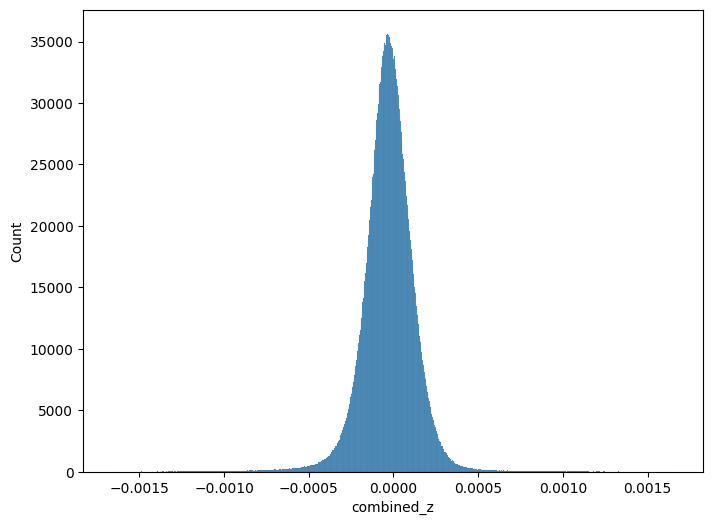

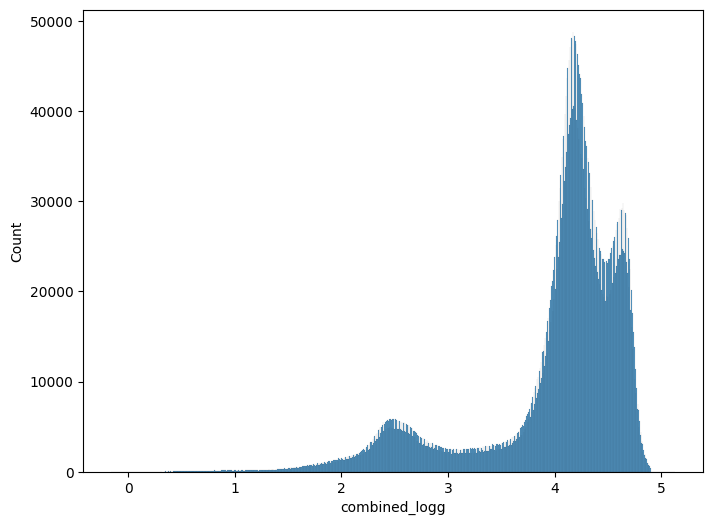

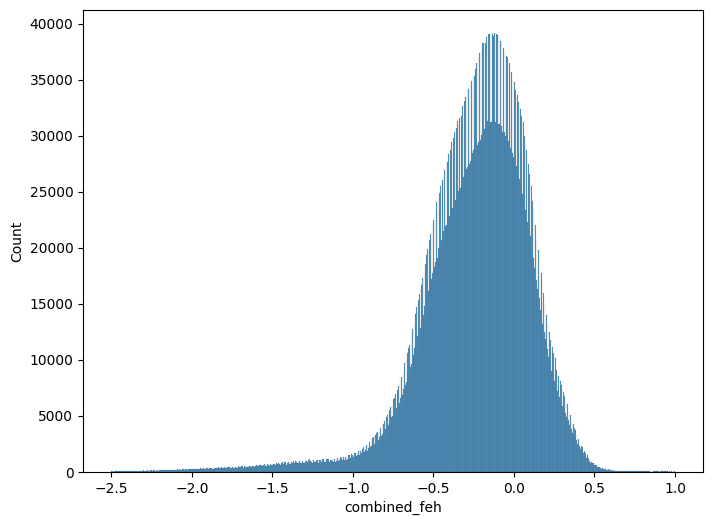

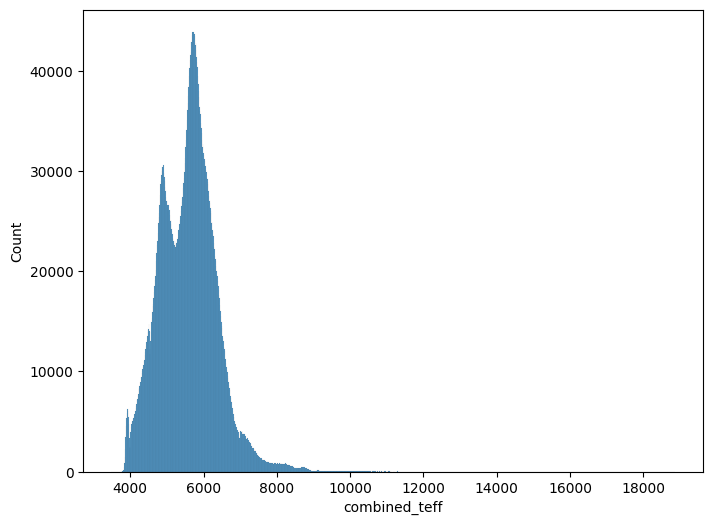

In [35]:
effective_features = ['combined_z', 'combined_logg', 'combined_feh', 'combined_teff']
for col in effective_features:
    figure = plt.figure(figsize=(8,6))
    sns.histplot(df[col])
plt.show()

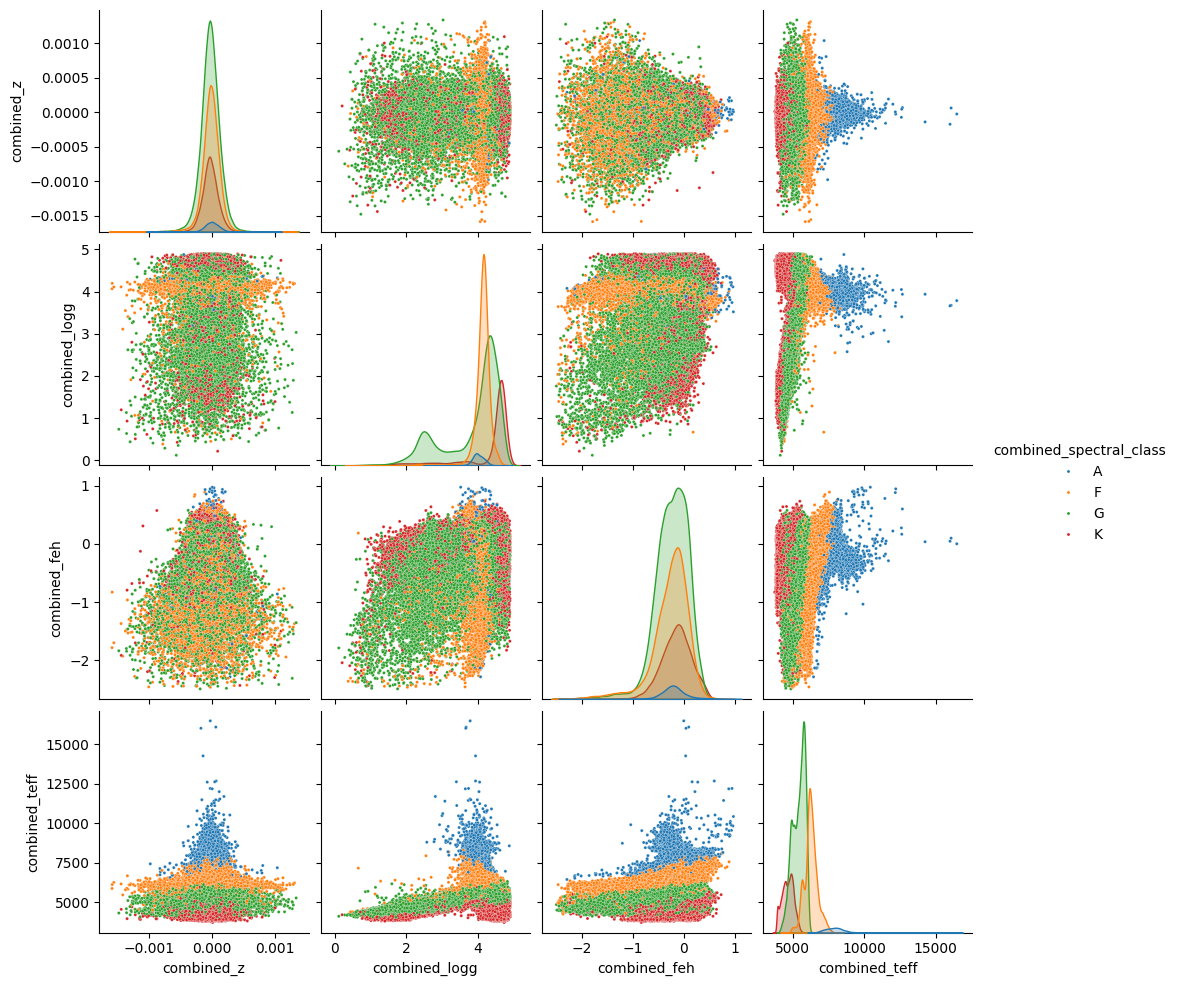

In [38]:
effective_features = ['combined_z', 'combined_logg', 'combined_feh', 'combined_teff']
sns.pairplot(
    df.sample(200000),
    vars=effective_features,
    hue='combined_spectral_class',
    hue_order=['A','F','G','K'],
    plot_kws={'s':5}
)
plt.show()

## Training

In [44]:
effective_features = ['combined_z', 'combined_logg', 'combined_feh', 'combined_teff']

X = df[features]
y = df['combined_spectral_class']

# Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [51]:

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [53]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

num_classes = len(le.classes_)
print(le.classes_)

['A' 'F' 'G' 'K']


In [54]:
model = Sequential([
    Dense(128, input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    Dropout(0.2),

    Dense(64),
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1770361290.684805      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770361290.691331      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [55]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [57]:
history = model.fit(
    X_train_scaled, y_train_enc,
    validation_data=(X_val_scaled, y_val_enc),
    epochs=100,
    batch_size=1024,
    class_weight=class_weight,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100


I0000 00:00:1770361344.136062     552 service.cc:152] XLA service 0x7cbc6c00fc80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770361344.136096     552 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770361344.136100     552 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770361344.628885     552 cuda_dnn.cc:529] Loaded cuDNN version 91002


  65/3927 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.6289 - loss: 0.9250

I0000 00:00:1770361347.260753     552 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3927/3927 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8557 - loss: 0.3670 - val_accuracy: 0.8251 - val_loss: 0.3683
Epoch 2/100
3927/3927 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8835 - loss: 0.2874 - val_accuracy: 0.7930 - val_loss: 0.4561
Epoch 3/100
3927/3927 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8844 - loss: 0.2843 - val_accuracy: 0.8800 - val_loss: 0.2937
Epoch 4/100
3927/3927 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8845 - loss: 0.2831 - val_accuracy: 0.8278 - val_loss: 0.3939
Epoch 5/100
3927/3927 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8851 - loss: 0.2828 - val_accuracy: 0.8824 - val_loss: 0.2847
Epoch 6/100
3927/3927 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8853 - loss: 0.2820 - val_accuracy: 0.8798 - val_loss: 0.3199
Epoch 7/100
3927/3927 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8851 - loss: 0.2821 - val_accuracy: 0.8815 - val_loss: 0.3151
Epoch 8/100
3927/3927 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8853 - loss: 0.281

In [58]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test_enc, y_pred, target_names=le.classes_))
print("Macro F1:", f1_score(y_test_enc, y_pred, average='macro'))

26923/26923 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step
              precision    recall  f1-score   support

           A       0.92      0.79      0.85     16961
           F       0.92      0.83      0.87    271171
           G       0.86      0.94      0.90    438468
           K       0.92      0.82      0.87    134926

    accuracy                           0.89    861526
   macro avg       0.91      0.85      0.87    861526
weighted avg       0.89      0.89      0.88    861526

Macro F1: 0.8723465418908296


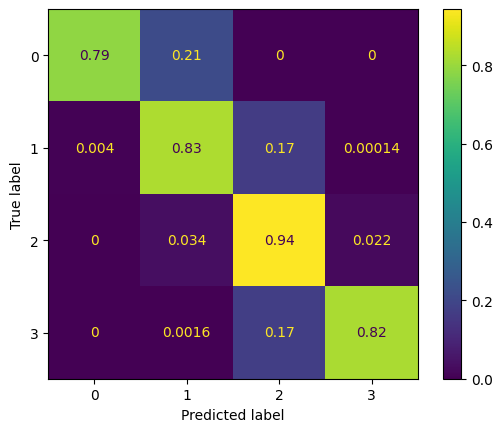

In [59]:
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, y_pred,
    normalize='true'
)